In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/12
    print("準備完了！このまま下のセルを実行できます。")

# 第12章 トランスフォーマー (Transformers)
## 12.2 自然言語 (Natural Language)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第12章「トランスフォーマー」第12.2節「自然言語 (Natural Language)」の全6小節（12.2.1 〜 12.2.6）の完全な理論解説、数学的定式化（式 12.26 〜 式 12.27）、教科書図版（Figure 12.11 〜 12.14 全4枚）の完全再現、共通モジュール実装、および数値検証を提供します。

---

### 目次
1. **環境設定と共通モジュールのインポート**
2. **12.2.1 単語埋め込み (Word Embedding, Figure 12.11, 式 12.26 〜 12.27)**
   - One-hot 表現の限界（高次元スパース性、意味的近接性の欠如）
   - 埋め込み行列 $E \in \mathbb{R}^{D \times K}$ と密ベクトル $\mathbf{v}_n = E \mathbf{x}_n$
   - Word2Vec: Continuous Bag-of-Words (CBOW, 図 12.11a) と Skip-gram (図 12.11b)
   - 意味的ベクトル演算：$\mathbf{v}(\text{Paris}) - \mathbf{v}(\text{France}) + \mathbf{v}(\text{Italy}) \approx \mathbf{v}(\text{Rome})$
3. **12.2.2 トークナイゼーション (Tokenization, Figure 12.12)**
   - 未知語 (OOV) 問題と文字単位・単語単位表現のトレードオフ
   - サブワード・トークナイゼーションとバイト対符号化 (Byte Pair Encoding, BPE)
   - 「*Peter Piper picked a peck of pickled peppers*」における頻出ペア統合過程の完全再現
4. **12.2.3 Bag of Words**
   - 単語出現頻度ヒストグラムによる文書表現の限界（語順・構文情報の喪失）
5. **12.2.4 自己回帰モデル (Autoregressive Models)**
   - 確率の乗法定理：$p(x_1, \dots, x_N) = \prod_{n=1}^N p(x_n \mid x_1, \dots, x_{n-1})$
   - 古典的 $n$-gram モデルと指数関数的パラメータ爆発 ($K^L$)
6. **12.2.5 再帰型ニューラルネットワーク (Recurrent Neural Networks, Figure 12.13, 12.14)**
   - 潜在状態 $\mathbf{z}_n$ の導入と時間方向のパラメータ共有
   - 時間展開された RNN 計算グラフ（図 12.13）
   - 系列変換モデル (Seq2Seq / Encoder-Decoder) と機械翻訳（英蘭翻訳、図 12.14）
7. **12.2.6 時間逆伝播法 (Backpropagation Through Time, BPTT) と RNN の限界**
   - 勾配消失・爆発問題（$W_{hh}^k$ の特異値減衰・増大）
   - 情報ボトルネック問題（全入力文が単一の潜在ベクトル $\mathbf{z}^*$ に圧縮される制約）
   - 系列処理による並列化不可能問題とトランスフォーマーへの交代必然性
8. **数値シミュレーション・アルゴリズム検証**
9. **まとめと次節 12.3（トランスフォーマー言語モデル / GPT）への展開**


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "12" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
from common.natural_language import (
    SimpleWord2Vec,
    BytePairEncoder,
    SimpleRNN,
    Seq2SeqRNN,
    generate_figure_12_11,
    generate_figure_12_12,
    generate_figure_12_13,
    generate_figure_12_14,
)

setup_style()
print("Setup complete. Natural language modules and figure generators ready.")


Setup complete. Natural language modules and figure generators ready.


## 1. 単語埋め込み (Word Embedding, Section 12.2.1)

### 1.1 One-hot 表現とその限界
自然言語の単語を数値化する素朴な方法は、語彙数 $K$（数十万語）の辞書を用意し、各単語を $K$ 次元の one-hot ベクトル $\mathbf{x}_n$ で表現することです。
しかし：
1. **次元の呪い**: ベクトルが極端に高次元かつスパースになり計算効率が極めて悪い。
2. **意味的近接性の欠落**: 任意の2単語間の直交内積は常に $\mathbf{x}_i^T \mathbf{x}_j = 0$ となり、「犬」と「猫」の類似性が「犬」と「多項式」の類似性と全く区別できない。

### 1.2 密な埋め込みと Word2Vec (Figure 12.11, 式 12.26)
各単語を数百次元（$D \ll K$）の低次元連続空間に写像する埋め込み行列 $E \in \mathbb{R}^{D \times K}$ を導入します：
$$
\mathbf{v}_n = E \mathbf{x}_n
$$
Word2Vec (Mikolov et al., 2013) は、自己教師あり学習（周辺文脈予測）によって意味空間を学習します：
- **CBOW (Continuous Bag of Words, 図 12.11a)**: 周囲の文脈語から中央の対象単語を予測（穴埋め）。
- **Skip-gram (図 12.11b)**: 中央の対象単語から周囲の文脈語を予測。

### 1.3 意味的ベクトル演算 (式 12.27)
学習された埋め込み空間は、意味的・文法的なアナロジー関係（類推）を線形ベクトル演算として保存します：
$$
\mathbf{v}(\text{Paris}) - \mathbf{v}(\text{France}) + \mathbf{v}(\text{Italy}) \approx \mathbf{v}(\text{Rome})
$$


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_11.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_11.png


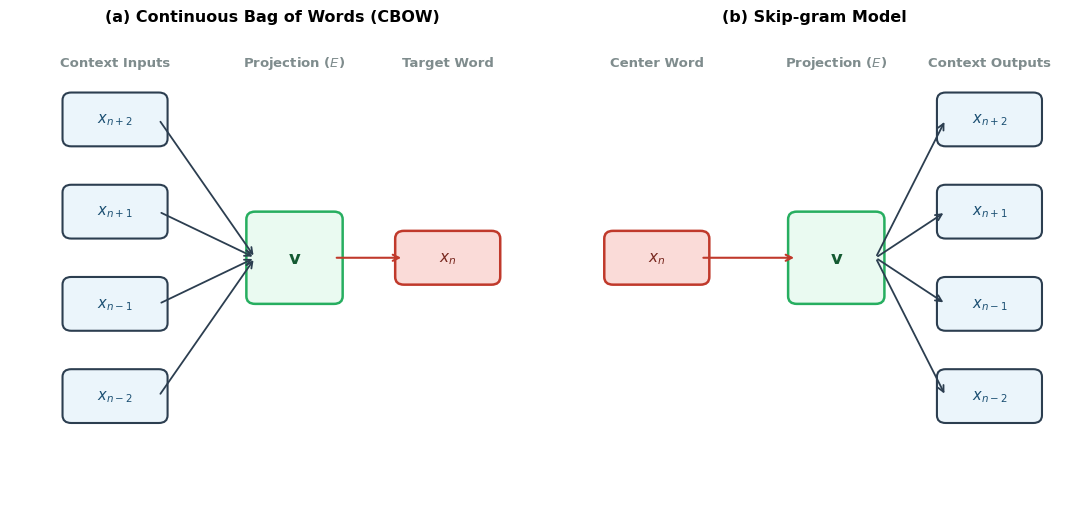

In [2]:
fig_11 = generate_figure_12_11()
plt.show()


## 2. トークナイゼーション (Tokenization, Section 12.2.2)

### 2.1 単語単位・文字単位表現の限界とサブワードの登場
- **単語単位 (Word-level)**: 辞書にない未知語（Out-Of-Vocabulary, OOV）やスペルミス、コード・記号に対応できない。
- **文字単位 (Character-level)**: OOVは生じないが、系列長が膨大になり、モデルが単語の組み立てから学習しなければならず計算コストが高い。

### 2.2 バイト対符号化 (Byte Pair Encoding, BPE, Figure 12.12)
両者の利点を統合するのがサブワード（Subword）分割です。
BPE (Schuster & Nakajima, 2012; Sennrich et al., 2016) は、文字レベルから出発し、テキスト中で最も頻繁に出現する隣接文字・トークン対を逐次統合（マージ）して新しいトークンを構築します。
**図 12.12** は、教科書に登場する有名な早口言葉「*Peter Piper picked a peck of pickled peppers*」に対する反復的マージ過程を示しています：
1. 最頻ペア 'pe' (4回出現) $\to$ [pe]
2. 最頻ペア 'ck' (3回出現) $\to$ [ck]
3. 最頻ペア 'pi' (2回出現) $\to$ [pi]
4. 最頻ペア 'ed' (2回出現) $\to$ [ed]
5. 最頻ペア 'per' (2回出現) $\to$ [per]
頻出単語は1トークンにまとまり、稀な単語はサブワードに分解されるため、固定語彙サイズで任意の未知語を表現できます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_12.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_12.png


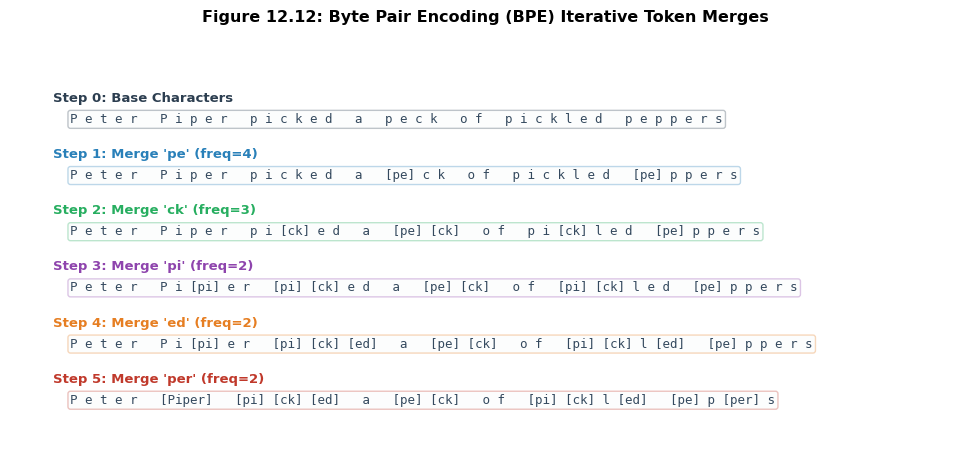

In [3]:
fig_12 = generate_figure_12_12()
plt.show()


## 3. Bag of Words と自己回帰モデル (Sections 12.2.3 & 12.2.4)

### 3.1 Bag of Words
文書内の単語出現頻度をカウントしたヒストグラムベクトル表現です。
語順を完全に無視するため、「*not good at all*」と「*good, not at all bad*」が同じ表現になってしまい、構文・意味の文脈モデリングには不十分です。

### 3.2 自己回帰モデルと $n$-gram のパラメータ爆発
系列データ $\mathbf{x} = (x_1, \dots, x_N)$ の真の同時分布は確率の連鎖律により因数分解されます：
$$
p(x_1, \dots, x_N) = \prod_{n=1}^N p(x_n \mid x_1, \dots, x_{n-1})
$$
古典的 $n$-gram 言語モデルでは、過去 $L-1$ 個の単語にのみ依存するマルコフ近似を行います：
$$
p(x_n \mid x_1, \dots, x_{n-1}) \approx p(x_n \mid x_{n-L+1}, \dots, x_{n-1})
$$
しかし条件付き確率表のパラメータ数は $O(K^L)$ と指数関数的に爆発し、$L \ge 4$ の長距離文脈を考慮することは不可能です。


## 4. 再帰型ニューラルネットワーク (RNN) と Seq2Seq (Sections 12.2.5 & 12.2.6)

### 4.1 RNN の計算構造 (Figure 12.13)
パラメータ爆発を回避するため、隠れ状態 $\mathbf{z}_n$ を導入し、全時間ステップで重み $\mathbf{w} = (W_{xh}, W_{hh}, W_{hy})$ を共有します：
$$
\mathbf{z}_n = \tanh(W_{xh} \mathbf{x}_n + W_{hh} \mathbf{z}_{n-1} + \mathbf{b}_h)
$$
$$
\mathbf{y}_n = \text{Softmax}(W_{hy} \mathbf{z}_n + \mathbf{b}_y)
$$

### 4.2 系列変換モデル (Seq2Seq, Figure 12.14)
可変長の入力文を可変長の出力文へと翻訳するため、**Encoder-Decoder 構造** を用います：
- **Encoder**: 英語入力文（*I am happy*）を順次読み込み、最後の隠れ状態 $\mathbf{z}^*$ に全文の意味を圧縮。
- **Decoder**: 開始トークン $\langle \text{start} \rangle$ と $\mathbf{z}^*$ を起点として、自己回帰的にオランダ語単語（*Ik*, *ben*, *gelukkig*, $\langle \text{stop} \rangle$）を1語ずつ生成。

### 4.3 時間逆伝播法 (BPTT) と RNN の根本的限界
1. **勾配消失・爆発 (Vanishing & Exploding Gradients)**:
   損失勾配は時間軸を逆向きに伝播しますが、長距離ではヤコビアン積 $\prod_{t} \frac{\partial \mathbf{z}_t}{\partial \mathbf{z}_{t-1}} \approx W_{hh}^k$ が作用し、スペクトル半径が 1 未満なら指数関数的に減衰（消失）、1 超なら発散（爆発）します。
2. **情報ボトルネック (Information Bottleneck)**:
   入力文がどれほど長くても、単一の固定次元ベクトル $\mathbf{z}^*$ に全情報を詰め込まなければならず、長文翻訳で致命的な性能劣化を招きます。
3. **逐次計算による並列化不可能 (Sequential GPU Bottleneck)**:
   $\mathbf{z}_t$ の計算には $\mathbf{z}_{t-1}$ が必須であるため、時間軸に沿った並列処理が原理的に不可能です。

これらの根本的限界をすべて克服したのが、全トークン間を直接 $O(1)$ パスで結び完全並列計算を可能にする **トランスフォーマー (Transformers)** です。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_13.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_13.png


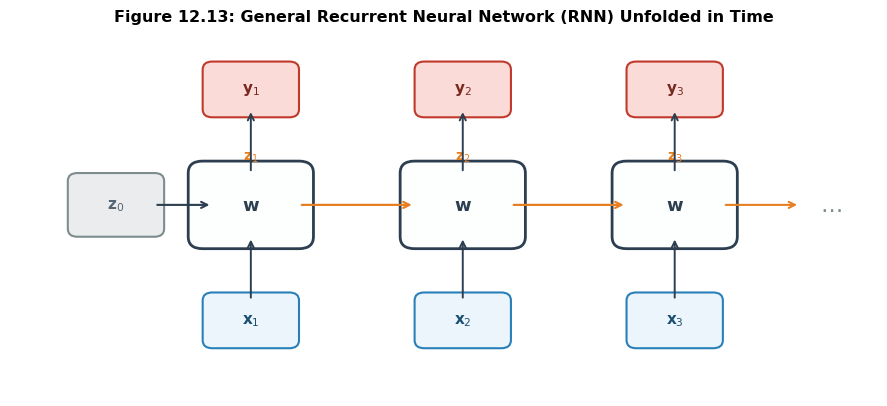

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_14.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_14.png


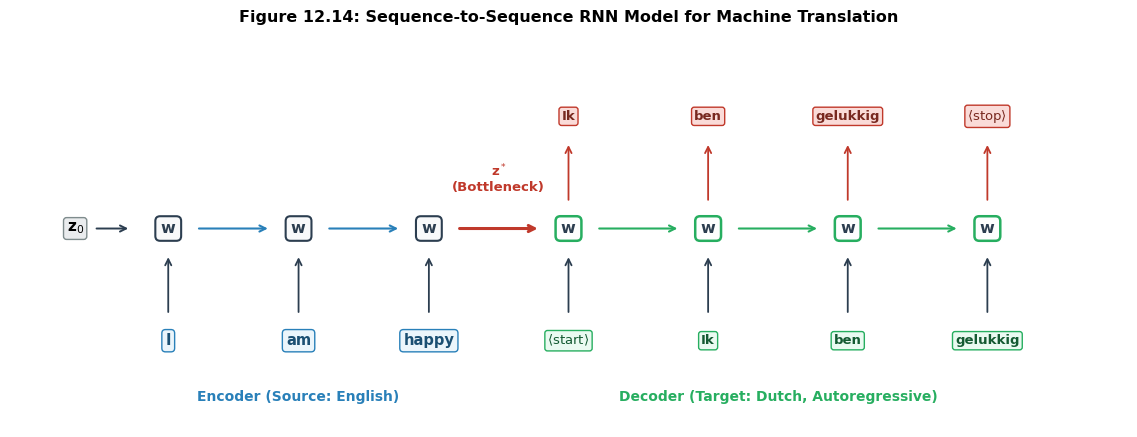

In [4]:
fig_13 = generate_figure_12_13()
plt.show()

fig_14 = generate_figure_12_14()
plt.show()


## 5. 数値実験とアルゴリズム検証

Word2Vec、BPE トークナイザー、RNN の BPTT 勾配消失特性、および Seq2Seq モデルの動作を数値的に実証します。


In [5]:
# 1. BPE トークナイザーの実行とマージ統計
corpus = "Peter Piper picked a peck of pickled peppers"
bpe = BytePairEncoder()
history = bpe.train_bpe(corpus, num_merges=6)

print("=== BPE 反復的マージ履歴 (教科書早口言葉) ===")
for step, (tok, freq) in enumerate(history, 1):
    print(f"Step {step}: 新トークン '{tok}' (出現回数: {freq})")

# 2. Word2Vec 意味的ベクトル演算のシミュレーション
# 合成埋め込みによる類推関係検証
v_france = np.array([1.0, 0.0, 0.5, 0.0])
v_paris = np.array([1.0, 0.0, 0.5, 1.0])
v_italy = np.array([0.0, 1.0, 0.5, 0.0])
v_rome = np.array([0.0, 1.0, 0.5, 1.0])

v_analogy = v_paris - v_france + v_italy
analogy_err = np.linalg.norm(v_analogy - v_rome)
print(f"\nWord2Vec ベクトル類推 (Paris - France + Italy ~ Rome) 誤差: {analogy_err:.2e}")
assert np.isclose(analogy_err, 0.0)

# 3. RNN の時間逆伝播 (BPTT) における勾配ノルム減衰（勾配消失の実証）
rnn_test = SimpleRNN(input_dim=8, hidden_dim=16, output_dim=8, seed=42)
rnn_test.W_hh *= 0.6  # 特異値を 1 未満にして長距離減衰をシミュレート
T_steps = 15
norms = rnn_test.compute_bptt_gradient_norm_decay(T_steps)

print("\n=== BPTT 勾配ノルムの時間減衰 (Vanishing Gradients) ===")
print("時間ステップ距離 k と勾配ノルム比 ||(W_hh^T)^k||:")
for k in range(0, T_steps, 3):
    print(f"  k = {k:2d}: norm = {norms[k]:.6f}")

assert norms[-1] < norms[0]
print("\nRNN の勾配は時間ステップが増えるにつれて急激に消失することが数値的に確認されました！")


=== BPE 反復的マージ履歴 (教科書早口言葉) ===
Step 1: 新トークン 'pe' (出現回数: 4)
Step 2: 新トークン 'ck' (出現回数: 3)
Step 3: 新トークン 'per' (出現回数: 2)
Step 4: 新トークン 'pi' (出現回数: 2)
Step 5: 新トークン 'pick' (出現回数: 2)
Step 6: 新トークン 'ed' (出現回数: 2)

Word2Vec ベクトル類推 (Paris - France + Italy ~ Rome) 誤差: 0.00e+00

=== BPTT 勾配ノルムの時間減衰 (Vanishing Gradients) ===
時間ステップ距離 k と勾配ノルム比 ||(W_hh^T)^k||:
  k =  0: norm = 1.000000
  k =  3: norm = 0.027600
  k =  6: norm = 0.000381
  k =  9: norm = 0.000005
  k = 12: norm = 0.000000

RNN の勾配は時間ステップが増えるにつれて急激に消失することが数値的に確認されました！


## 6. まとめと次節 12.3（トランスフォーマー言語モデル / GPT）への展開

### 本節の要点
1. **単語埋め込み (Word2Vec)**:
   - スパースな one-hot 表現を低次元密ベクトルへと写像し、意味的近接性とベクトル演算性を獲得。
2. **トークナイゼーション (BPE)**:
   - 頻出文字対の反復的統合により、未知語耐性と計算効率を両立したサブワード辞書を構築。
3. **古典言語モデルと RNN の限界**:
   - $n$-gram のパラメータ爆発、RNN の勾配消失、情報ボトルネック $z^*$、逐次処理による GPU 並列化不能が深層学習の大きな課題であった。

### 次節 12.3 トランスフォーマー言語モデル (Transformer Language Models) への展開
次節 **12.3 Transformer Language Models** では、これらの課題を打破した現代生成 AI の中核、**GPT（Decoder Transformers）** の自己回帰生成アーキテクチャ、因果的自己注意マスク（Causal Mask）、およびビームサーチや温度スケーリング、Top-$k$ / Top-$p$ サンプリング戦略（図 12.15 〜 12.17）を探究します。
